# Milestone 3 - GradientBoostingRegressor Training and Evaluation

This notebook trains and evaluates only the `GradientBoostingRegressor`-based quantile models used in this project.

Model source:
- `core/models/probabilistic_quantile.py`

Evaluation scope:
- One-step-ahead target (`target_log_ret_1d`)
- Quantile metrics (pinball loss)
- Point metrics from median quantile (`q_0.50`)
- Coverage and quantile diagnostics


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'core').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from core.models.probabilistic_quantile import (
    DEFAULT_FEATURES,
    add_next_day_target,
    prepare_model_frame,
    time_split,
    fit_quantile_models,
    predict_quantiles,
)

print('Project root:', ROOT)


Project root: C:\Users\sia\Desktop\capstone\src\Agentic-Crypto-Return-Service


In [2]:
# ------------------------------
# Configuration
# ------------------------------
FEATURE_DIR = ROOT / 'data' / 'processed' / 'features'

TRAIN_FRAC = 0.80
QUANTILES = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
RANDOM_STATE = 42
N_ESTIMATORS = 200
LEARNING_RATE = 0.05
MAX_DEPTH = 3

hyperparams_df = pd.DataFrame([
    ('TRAIN_FRAC', TRAIN_FRAC),
    ('QUANTILES', QUANTILES),
    ('RANDOM_STATE', RANDOM_STATE),
    ('N_ESTIMATORS', N_ESTIMATORS),
    ('LEARNING_RATE', LEARNING_RATE),
    ('MAX_DEPTH', MAX_DEPTH),
    ('FEATURES', DEFAULT_FEATURES),
], columns=['hyperparameter', 'value'])

display(hyperparams_df)


,hyperparameter,value
0,TRAIN_FRAC,0.8
1,QUANTILES,"[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, ..."
2,RANDOM_STATE,42
3,N_ESTIMATORS,200
4,LEARNING_RATE,0.05
5,MAX_DEPTH,3
6,FEATURES,"[log_ret_1d, log_ret_5d, log_ret_10d, vol_7d, ..."


In [3]:
# ------------------------------
# Helpers
# ------------------------------
def load_features_safe(fp: Path) -> pd.DataFrame:
    """Robust CSV loader that tolerates bad date rows (e.g., merge markers)."""
    df = pd.read_csv(fp)
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)
    if 'close' in df.columns:
        df['close'] = pd.to_numeric(df['close'], errors='coerce')
        df = df.dropna(subset=['close']).reset_index(drop=True)
    return df


def pinball_loss(y_true: np.ndarray, y_pred: np.ndarray, q: float) -> float:
    e = y_true - y_pred
    return float(np.mean(np.maximum(q * e, (q - 1.0) * e)))


def quantile_crossing_rate(qpred: pd.DataFrame, quantiles: list[float]) -> float:
    cols = [f'q_{q:.2f}' for q in sorted(quantiles)]
    arr = qpred[cols].to_numpy(dtype=float)
    crossing = np.any(np.diff(arr, axis=1) < 0, axis=1)
    return float(np.mean(crossing))


def empirical_coverage(y_true: np.ndarray, qpred: pd.DataFrame, q: float) -> float:
    col = f'q_{q:.2f}'
    return float(np.mean(y_true <= qpred[col].to_numpy(dtype=float)))


In [4]:
# ------------------------------
# Train and evaluate per coin
# ------------------------------
feature_files = sorted(FEATURE_DIR.glob('*_features.csv'))
print(f'Feature files found: {len(feature_files)}')

coin_rows = []
pinball_rows = []
coverage_rows = []
curve_rows = []
pred_store = {}
errors = []

for fp in feature_files:
    try:
        df = load_features_safe(fp)
        df = add_next_day_target(df, ret_col='log_ret_1d')
        model_df, feats, target_col = prepare_model_frame(df, feature_cols=DEFAULT_FEATURES)

        train_df, test_df = time_split(model_df, train_frac=TRAIN_FRAC)
        bundle = fit_quantile_models(
            train_df=train_df,
            feature_cols=feats,
            target_col=target_col,
            quantiles=QUANTILES,
            random_state=RANDOM_STATE,
            n_estimators=N_ESTIMATORS,
            learning_rate=LEARNING_RATE,
            max_depth=MAX_DEPTH,
        )

        qpred = predict_quantiles(bundle, test_df)
        y_true = test_df[target_col].to_numpy(dtype=float)

        coin = str(df['ticker'].dropna().iloc[-1]) if 'ticker' in df.columns and df['ticker'].notna().any() else fp.stem

        # Per-quantile pinball
        for q in QUANTILES:
            pinball_rows.append({
                'coin': coin,
                'quantile': float(q),
                'pinball_loss': pinball_loss(y_true, qpred[f'q_{q:.2f}'].to_numpy(dtype=float), q),
            })

        # Empirical CDF coverage by quantile
        for q in QUANTILES:
            coverage_rows.append({
                'coin': coin,
                'quantile': float(q),
                'nominal_q': float(q),
                'empirical_coverage': empirical_coverage(y_true, qpred, q),
                'abs_calibration_error': abs(empirical_coverage(y_true, qpred, q) - q),
            })

        q50 = qpred['q_0.50'].to_numpy(dtype=float)
        residual = q50 - y_true

        coin_rows.append({
            'coin': coin,
            'n_train': int(len(train_df)),
            'n_test': int(len(test_df)),
            'mae_q50': float(np.mean(np.abs(residual))),
            'rmse_q50': float(np.sqrt(np.mean(residual ** 2))),
            'direction_accuracy_q50': float(np.mean(np.sign(q50) == np.sign(y_true))),
            'coverage_90': float(np.mean((y_true >= qpred['q_0.05'].to_numpy(dtype=float)) & (y_true <= qpred['q_0.95'].to_numpy(dtype=float)))),
            'mean_pinball': float(np.mean([r['pinball_loss'] for r in pinball_rows if r['coin'] == coin])),
            'crossing_rate': quantile_crossing_rate(qpred, QUANTILES),
        })

        # Training curve from GradientBoostingRegressor.train_score_
        for q in QUANTILES:
            ts = bundle.models[float(q)].train_score_
            for i, score in enumerate(ts, start=1):
                curve_rows.append({
                    'coin': coin,
                    'quantile': float(q),
                    'iter': int(i),
                    'train_loss': float(score),
                })

        pred_store[coin] = pd.DataFrame({
            'date': test_df['date'].to_numpy(),
            'y_true': y_true,
            'q_0.05': qpred['q_0.05'].to_numpy(dtype=float),
            'q_0.50': qpred['q_0.50'].to_numpy(dtype=float),
            'q_0.95': qpred['q_0.95'].to_numpy(dtype=float),
        })

    except Exception as e:
        errors.append({'file': str(fp), 'error': str(e)})

coin_metrics_df = pd.DataFrame(coin_rows).sort_values('coin').reset_index(drop=True)
pinball_df = pd.DataFrame(pinball_rows).sort_values(['coin', 'quantile']).reset_index(drop=True)
coverage_df = pd.DataFrame(coverage_rows).sort_values(['coin', 'quantile']).reset_index(drop=True)
curve_df = pd.DataFrame(curve_rows).sort_values(['coin', 'quantile', 'iter']).reset_index(drop=True)
errors_df = pd.DataFrame(errors)

print('Trained coins:', len(coin_metrics_df))
print('Errors:', len(errors_df))
if not errors_df.empty:
    display(errors_df)

display(coin_metrics_df)


Feature files found: 10


C:\Users\sia\AppData\Local\Temp\ipykernel_7992\3314532411.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')
C:\Users\sia\AppData\Local\Temp\ipykernel_7992\3314532411.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


Trained coins: 10
Errors: 0


,coin,n_train,n_test,mae_q50,rmse_q50,direction_accuracy_q50,coverage_90,mean_pinball,crossing_rate
0,ADA-USD,2707,677,0.032542,0.044566,0.454948,0.927622,0.007850,0.008863
1,AVAX-USD,1870,468,0.032821,0.047556,0.653846,0.925214,0.008091,0.008547
2,BNB-USD,3472,868,0.016575,0.026387,0.718894,0.925115,0.004187,0.154378
3,BTC-USD,5057,1265,0.014431,0.022570,0.740711,0.917787,0.003594,0.097233
4,DOGE-USD,2707,677,0.035234,0.048229,0.412112,0.905465,0.008323,0.005908
5,ETH-USD,4176,1045,0.021407,0.034599,0.738756,0.901435,0.005500,0.165550
6,FLOKI-USD,2344,587,0.033658,0.054176,0.652470,0.902896,0.008742,0.277683
7,LINK-USD,2707,677,0.033716,0.045873,0.410635,0.935007,0.008085,0.011817
8,SOL-USD,2569,643,0.022886,0.034841,0.765163,0.942457,0.005933,0.153966
9,XRP-USD,2429,608,0.031065,0.047460,0.472039,0.906250,0.007886,0.044408


In [5]:
# Aggregate summary
if coin_metrics_df.empty:
    raise RuntimeError('No evaluation rows produced.')

summary_df = pd.DataFrame([{
    'coins': int(len(coin_metrics_df)),
    'avg_mae_q50': float(coin_metrics_df['mae_q50'].mean()),
    'avg_rmse_q50': float(coin_metrics_df['rmse_q50'].mean()),
    'avg_direction_accuracy_q50': float(coin_metrics_df['direction_accuracy_q50'].mean()),
    'avg_coverage_90': float(coin_metrics_df['coverage_90'].mean()),
    'avg_mean_pinball': float(coin_metrics_df['mean_pinball'].mean()),
    'avg_crossing_rate': float(coin_metrics_df['crossing_rate'].mean()),
}])

display(summary_df)


,coins,avg_mae_q50,avg_rmse_q50,avg_direction_accuracy_q50,avg_coverage_90,avg_mean_pinball,avg_crossing_rate
0,10,0.027434,0.040626,0.601958,0.918925,0.006819,0.092835


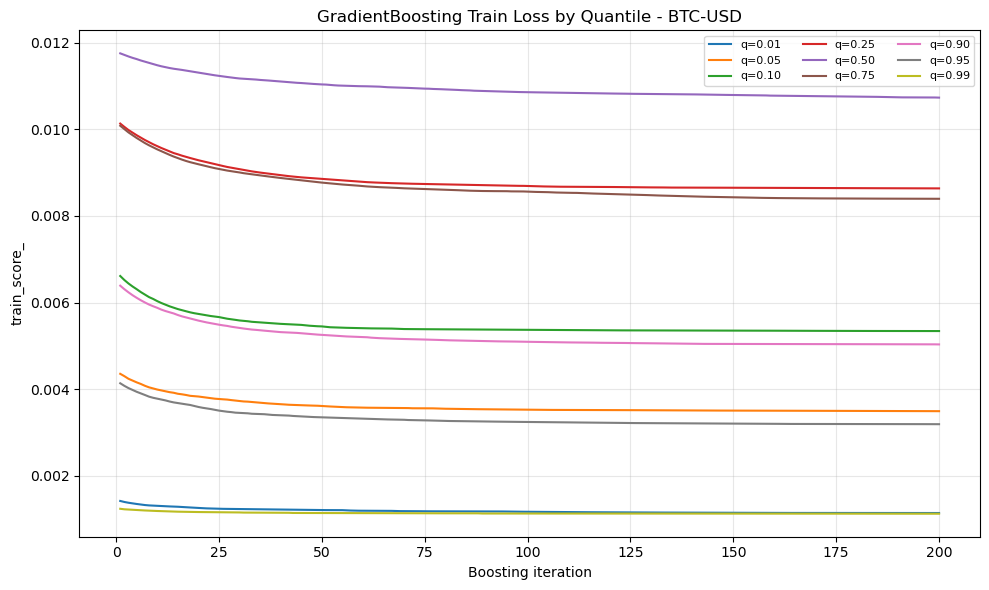

In [6]:
# Plot 1: Training loss curves (sample coin)
sample_coin = 'BTC-USD' if 'BTC-USD' in set(curve_df['coin']) else curve_df['coin'].iloc[0]
plot_df = curve_df[curve_df['coin'] == sample_coin]

fig, ax = plt.subplots(figsize=(10, 6))
for q in sorted(plot_df['quantile'].unique()):
    g = plot_df[plot_df['quantile'] == q]
    ax.plot(g['iter'], g['train_loss'], label=f'q={q:.2f}', linewidth=1.5)

ax.set_title(f'GradientBoosting Train Loss by Quantile - {sample_coin}')
ax.set_xlabel('Boosting iteration')
ax.set_ylabel('train_score_')
ax.grid(alpha=0.3)
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


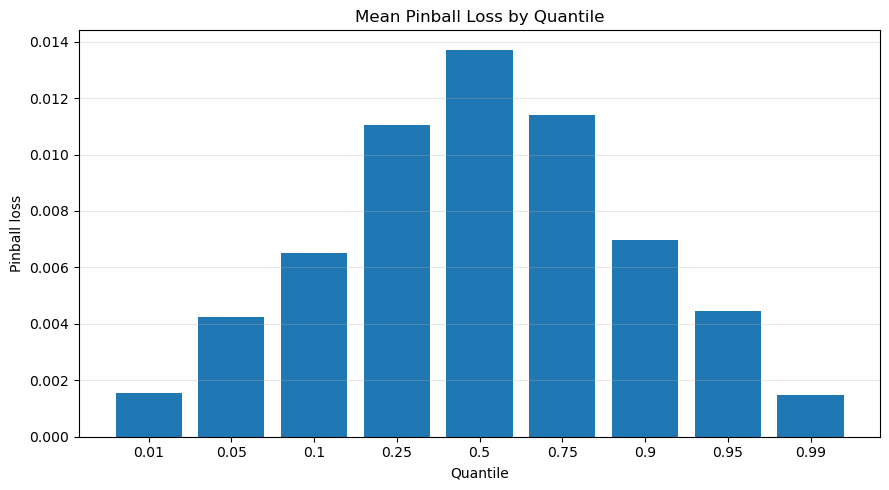

In [7]:
# Plot 2: Mean pinball loss by quantile
pb_mean = pinball_df.groupby('quantile', as_index=False)['pinball_loss'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(pb_mean['quantile'].astype(str), pb_mean['pinball_loss'])
ax.set_title('Mean Pinball Loss by Quantile')
ax.set_xlabel('Quantile')
ax.set_ylabel('Pinball loss')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


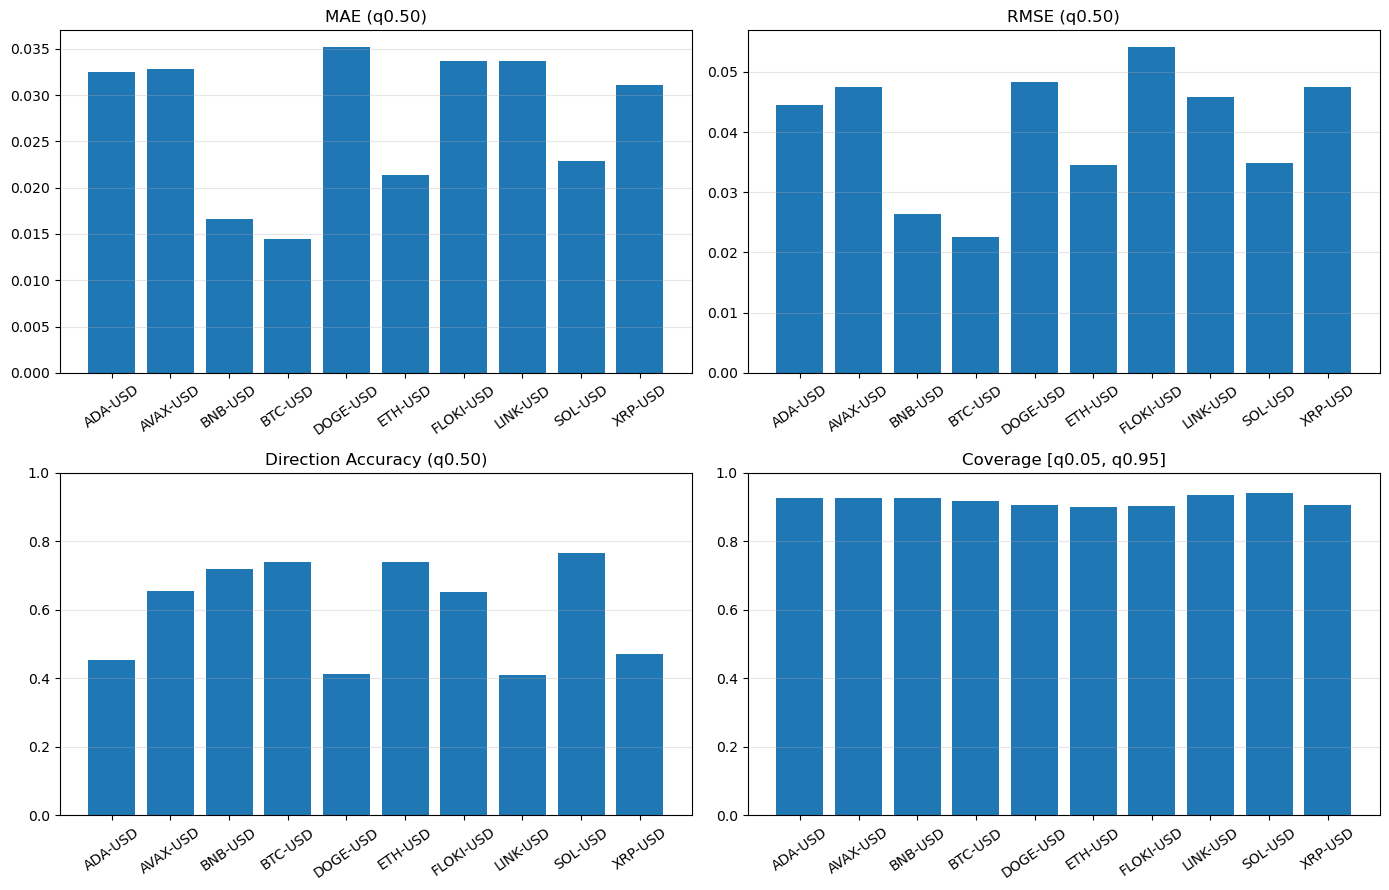

In [8]:
# Plot 3: Per-coin main metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
mdf = coin_metrics_df.sort_values('coin')

axes[0, 0].bar(mdf['coin'], mdf['mae_q50'])
axes[0, 0].set_title('MAE (q0.50)')
axes[0, 0].tick_params(axis='x', rotation=35)
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].bar(mdf['coin'], mdf['rmse_q50'])
axes[0, 1].set_title('RMSE (q0.50)')
axes[0, 1].tick_params(axis='x', rotation=35)
axes[0, 1].grid(axis='y', alpha=0.3)

axes[1, 0].bar(mdf['coin'], mdf['direction_accuracy_q50'])
axes[1, 0].set_title('Direction Accuracy (q0.50)')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis='x', rotation=35)
axes[1, 0].grid(axis='y', alpha=0.3)

axes[1, 1].bar(mdf['coin'], mdf['coverage_90'])
axes[1, 1].set_title('Coverage [q0.05, q0.95]')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis='x', rotation=35)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


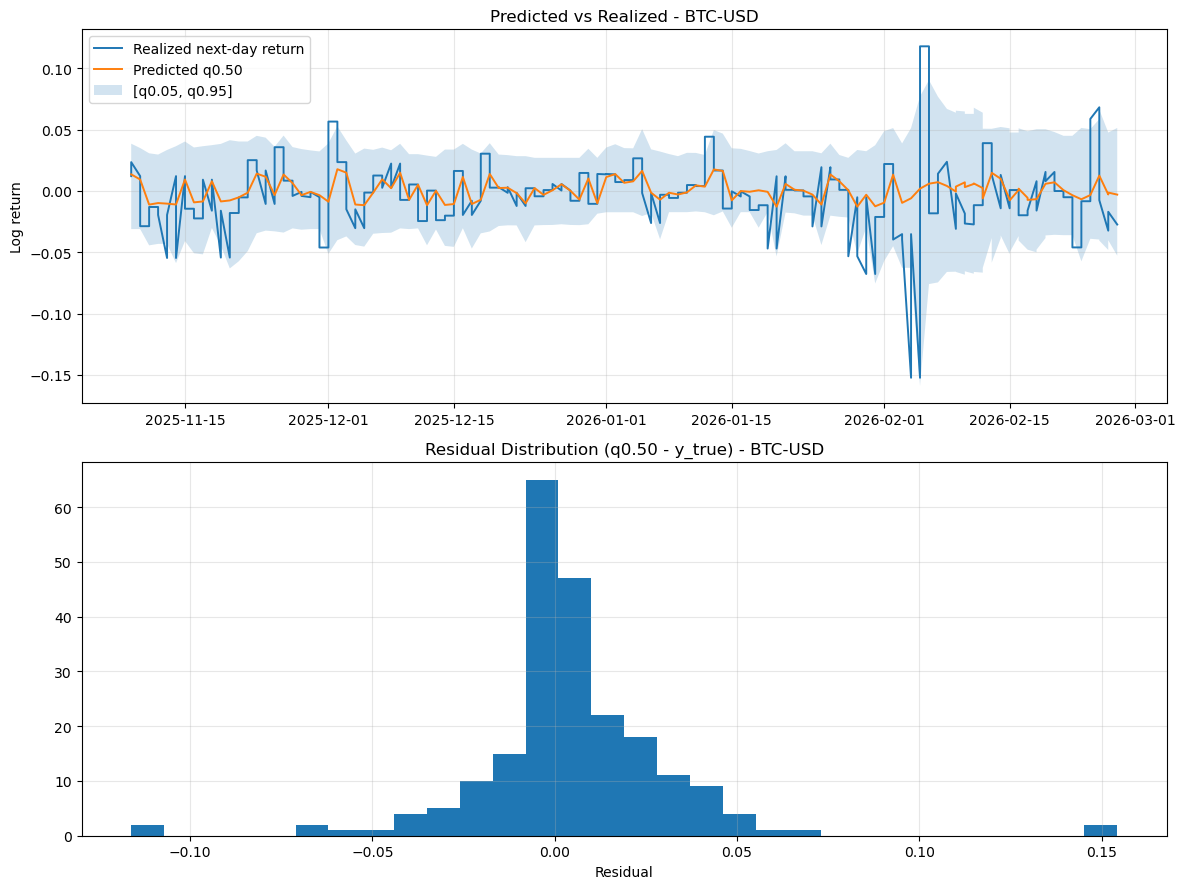

In [9]:
# Plot 4: Prediction diagnostics for sample coin
coin = 'BTC-USD' if 'BTC-USD' in pred_store else list(pred_store.keys())[0]
g = pred_store[coin].sort_values('date').tail(220)

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

axes[0].plot(g['date'], g['y_true'], label='Realized next-day return', linewidth=1.4)
axes[0].plot(g['date'], g['q_0.50'], label='Predicted q0.50', linewidth=1.4)
axes[0].fill_between(g['date'], g['q_0.05'], g['q_0.95'], alpha=0.2, label='[q0.05, q0.95]')
axes[0].set_title(f'Predicted vs Realized - {coin}')
axes[0].set_ylabel('Log return')
axes[0].grid(alpha=0.3)
axes[0].legend()

residual = g['q_0.50'] - g['y_true']
axes[1].hist(residual, bins=30)
axes[1].set_title(f'Residual Distribution (q0.50 - y_true) - {coin}')
axes[1].set_xlabel('Residual')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


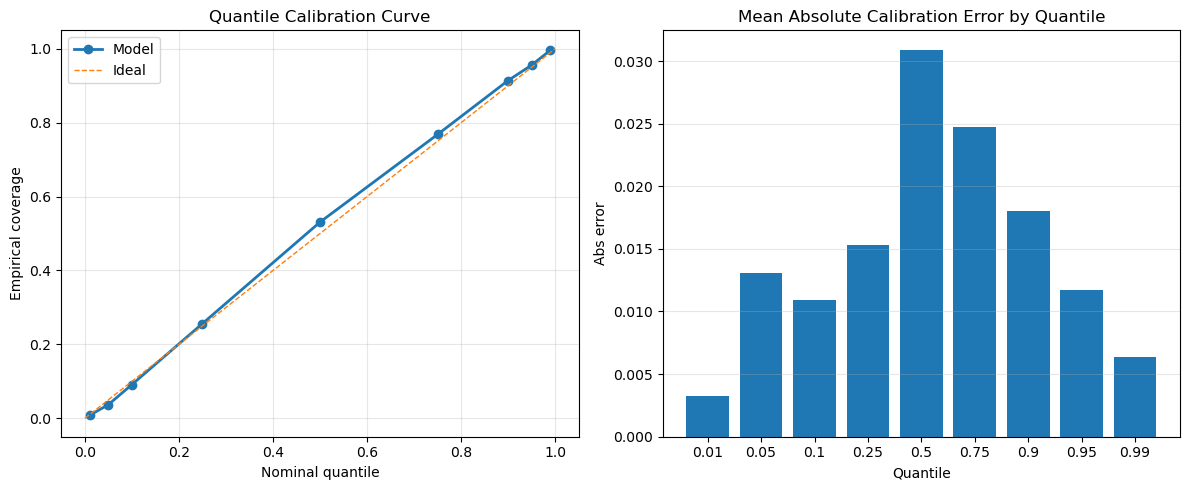

In [10]:
# Plot 5: Quantile calibration curve (empirical coverage vs nominal quantile)
cal = coverage_df.groupby('quantile', as_index=False).agg(
    nominal_q=('nominal_q', 'mean'),
    empirical_coverage=('empirical_coverage', 'mean'),
    abs_calibration_error=('abs_calibration_error', 'mean'),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(cal['nominal_q'], cal['empirical_coverage'], marker='o', linewidth=2, label='Model')
axes[0].plot([0, 1], [0, 1], linestyle='--', linewidth=1, label='Ideal')
axes[0].set_title('Quantile Calibration Curve')
axes[0].set_xlabel('Nominal quantile')
axes[0].set_ylabel('Empirical coverage')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].bar(cal['quantile'].astype(str), cal['abs_calibration_error'])
axes[1].set_title('Mean Absolute Calibration Error by Quantile')
axes[1].set_xlabel('Quantile')
axes[1].set_ylabel('Abs error')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Conclusion

This notebook reports training and evaluation results for only the `GradientBoostingRegressor` quantile models used in the project.

If you need, the next step can be exporting `coin_metrics_df`, `pinball_df`, and `coverage_df` to CSV files for your Milestone report.
